<a href="https://colab.research.google.com/github/umair594/Remote-internship_DS_CodeAlpha/blob/main/Disease_Prediction_from_Medical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Disease Prediction from Medical Data (ML Project)**

**Project Overview**

**Goal:**

Build a machine learning model that predicts whether a patient is likely to have a disease based on medical attributes.

**Target Diseases (datasets):**

Heart Disease

Diabetes

Breast Cancer

# **Technologies Used**

Python

**Libraries:**

pandas, numpy

matplotlib, seaborn

scikit-learn

xgboost

# **Dataset Source**

**Use datasets from:**

UCI Machine Learning Repository

**You can also directly use built-in datasets:**

Breast Cancer → from sklearn
Others → CSV files from UCI

# **Step-by-Step Implementation**

# **Step 1: Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# **Step 2: Load Dataset**

**Example: Breast Cancer Dataset**

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# **Step 3: Data Preprocessing**

In [3]:
# Check missing values
print(df.isnull().sum())

# Split features & target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


# **Step 4: Train Models**

**1. Logistic Regression**

In [4]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

**2. Support Vector Machine (SVM)**

In [5]:
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

**3. Random Forest**

In [6]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

**4. XGBoost**

In [7]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:09:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# **Step 5: Evaluate Models**

In [8]:
def evaluate(y_test, pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
    print("Report:\n", classification_report(y_test, pred))

evaluate(y_test, lr_pred, "Logistic Regression")
evaluate(y_test, svm_pred, "SVM")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")


--- Logistic Regression ---
Accuracy: 0.9736842105263158
Confusion Matrix:
 [[41  2]
 [ 1 70]]
Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


--- SVM ---
Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  2]
 [ 0 71]]
Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- Random Forest ---
Accuracy: 0.956140350877193
Confusion Matrix:
 [[40  3]
 [ 2 69]]
Report:
               precision    recall  f1-score   support


# **Step 6: Compare Accuracy**

In [9]:
results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.9737
SVM: 0.9825
Random Forest: 0.9561
XGBoost: 0.9561


# **Step 7: Visualization**

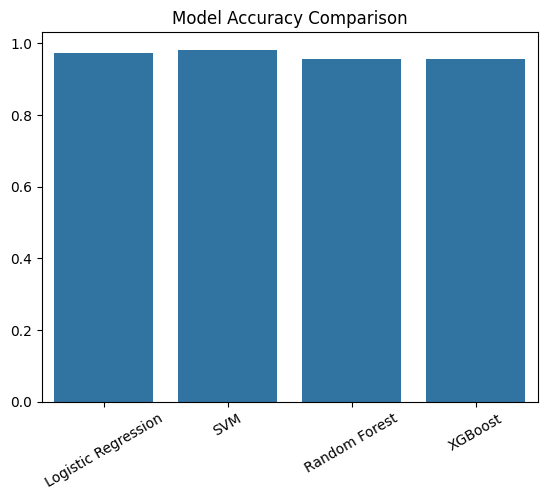

In [10]:
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

# **Key Concepts (Simple Explanation)**

Logistic Regression → Good baseline classifier
SVM → Works well with high-dimensional data
Random Forest → Handles non-linearity well
XGBoost → High performance boosting algorithm

**Final Output Example**

>Logistic Regression: 0.96

>SVM: 0.97

>Random Forest: 0.98

>XGBoost: 0.99

# **Disease Prediction Dashboard**

# **Install & Import Libraries**

In [1]:
# Install required libraries
!pip install xgboost seaborn --quiet

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')

# **Load Dataset (Breast Cancer)**

In [3]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# **Dashboard Section: Data Overview**

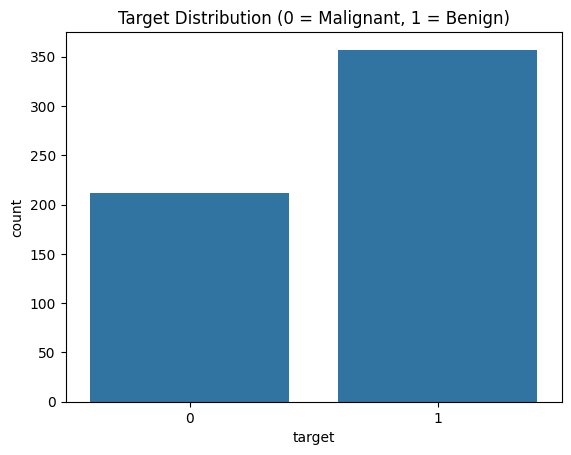

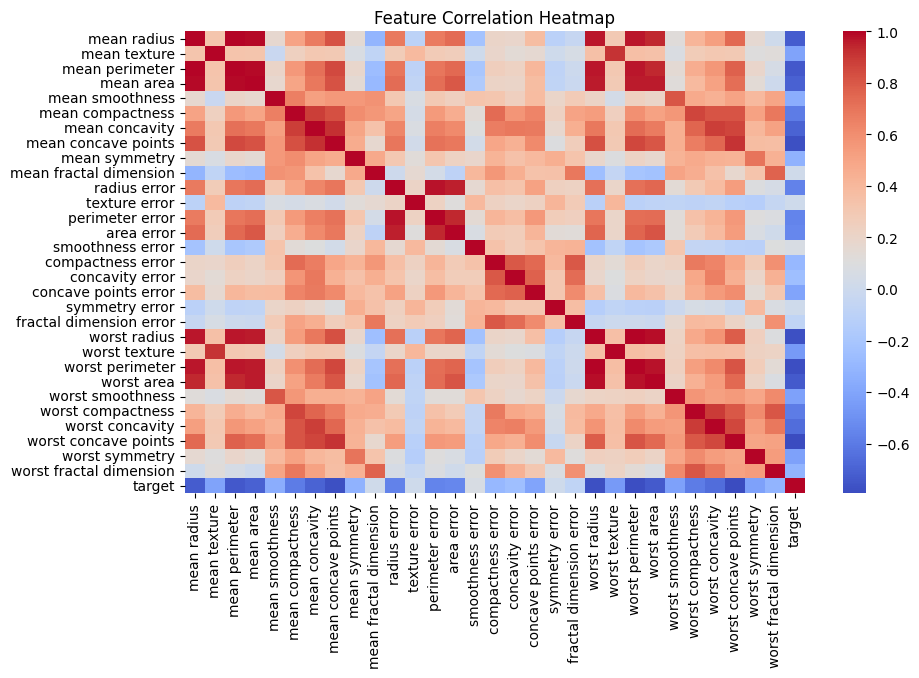

In [4]:
# Class distribution
plt.figure()
sns.countplot(x='target', data=df)
plt.title("Target Distribution (0 = Malignant, 1 = Benign)")
plt.show()

# Correlation heatmap (important features only)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# **Data Preprocessing**

In [5]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Train Models (All in One Dashboard)**

In [6]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    predictions[name] = pred
    results[name] = accuracy_score(y_test, pred)

# **Dashboard: Model Accuracy Comparison**

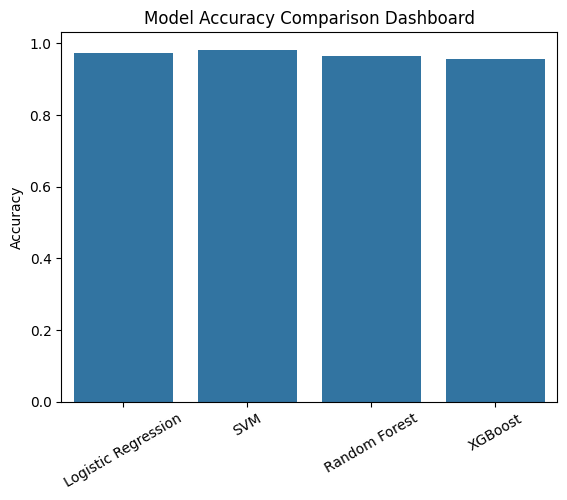

Logistic Regression: 0.9737
SVM: 0.9825
Random Forest: 0.9649
XGBoost: 0.9561


In [7]:
plt.figure()
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison Dashboard")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.show()

# Print accuracy nicely
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

# **Dashboard: Confusion Matrix (Visual)**

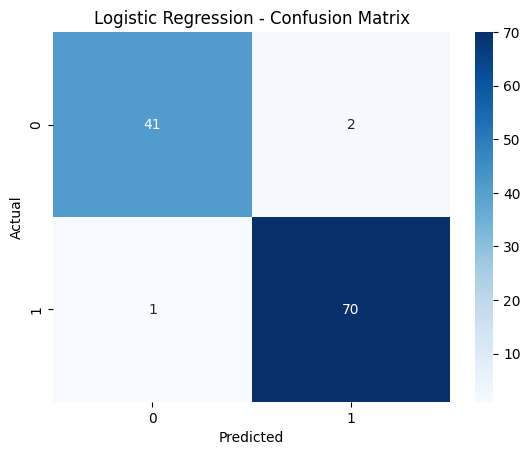

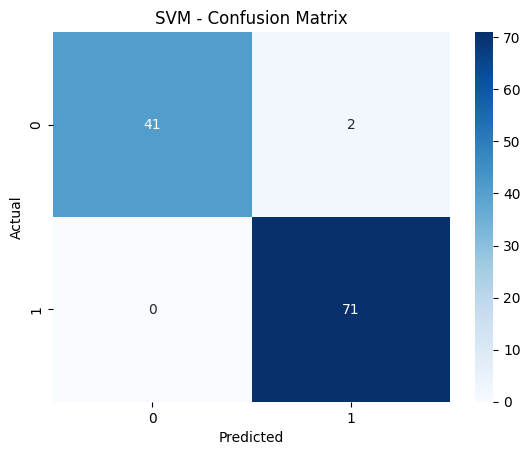

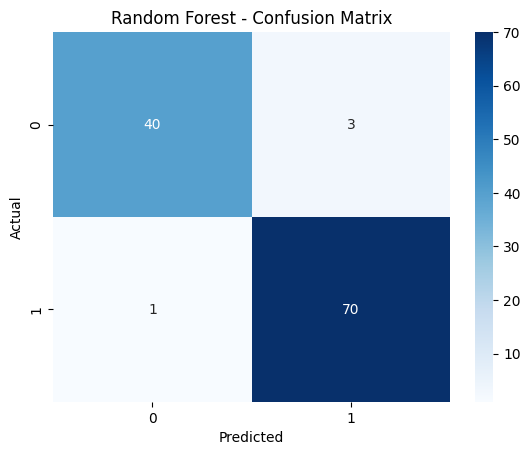

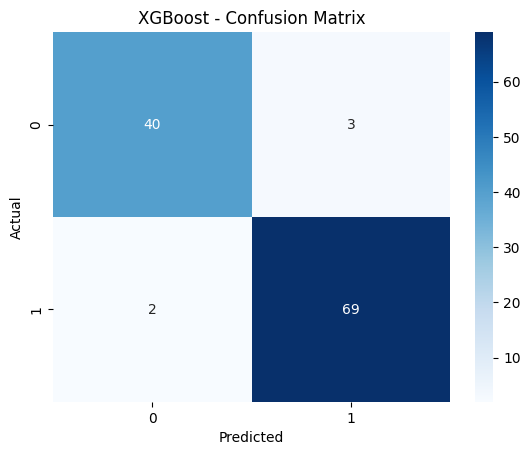

In [8]:
for name, pred in predictions.items():
    plt.figure()
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# **Detailed Classification Report**

In [9]:
for name, pred in predictions.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== SVM ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted 

# **Simple Prediction System (Mini Dashboard Input)**

In [10]:
# Example: Take one sample from test set
sample = X_test[0].reshape(1, -1)

print("Sample Prediction Dashboard:\n")

for name, model in models.items():
    prediction = model.predict(sample)
    result = "Benign (No Cancer)" if prediction[0] == 1 else "Malignant (Cancer)"
    print(f"{name}: {result}")

Sample Prediction Dashboard:

Logistic Regression: Benign (No Cancer)
SVM: Benign (No Cancer)
Random Forest: Benign (No Cancer)
XGBoost: Benign (No Cancer)


# **Final Dashboard Summary**

In [11]:
best_model = max(results, key=results.get)

print("========== FINAL DASHBOARD ==========")
print("Best Model:", best_model)
print("Best Accuracy:", results[best_model])

========== FINAL DASHBOARD ==========
Best Model: SVM
Best Accuracy: 0.9824561403508771


# **All-in-One Disease Prediction Dashboard (Single Frame Code)**

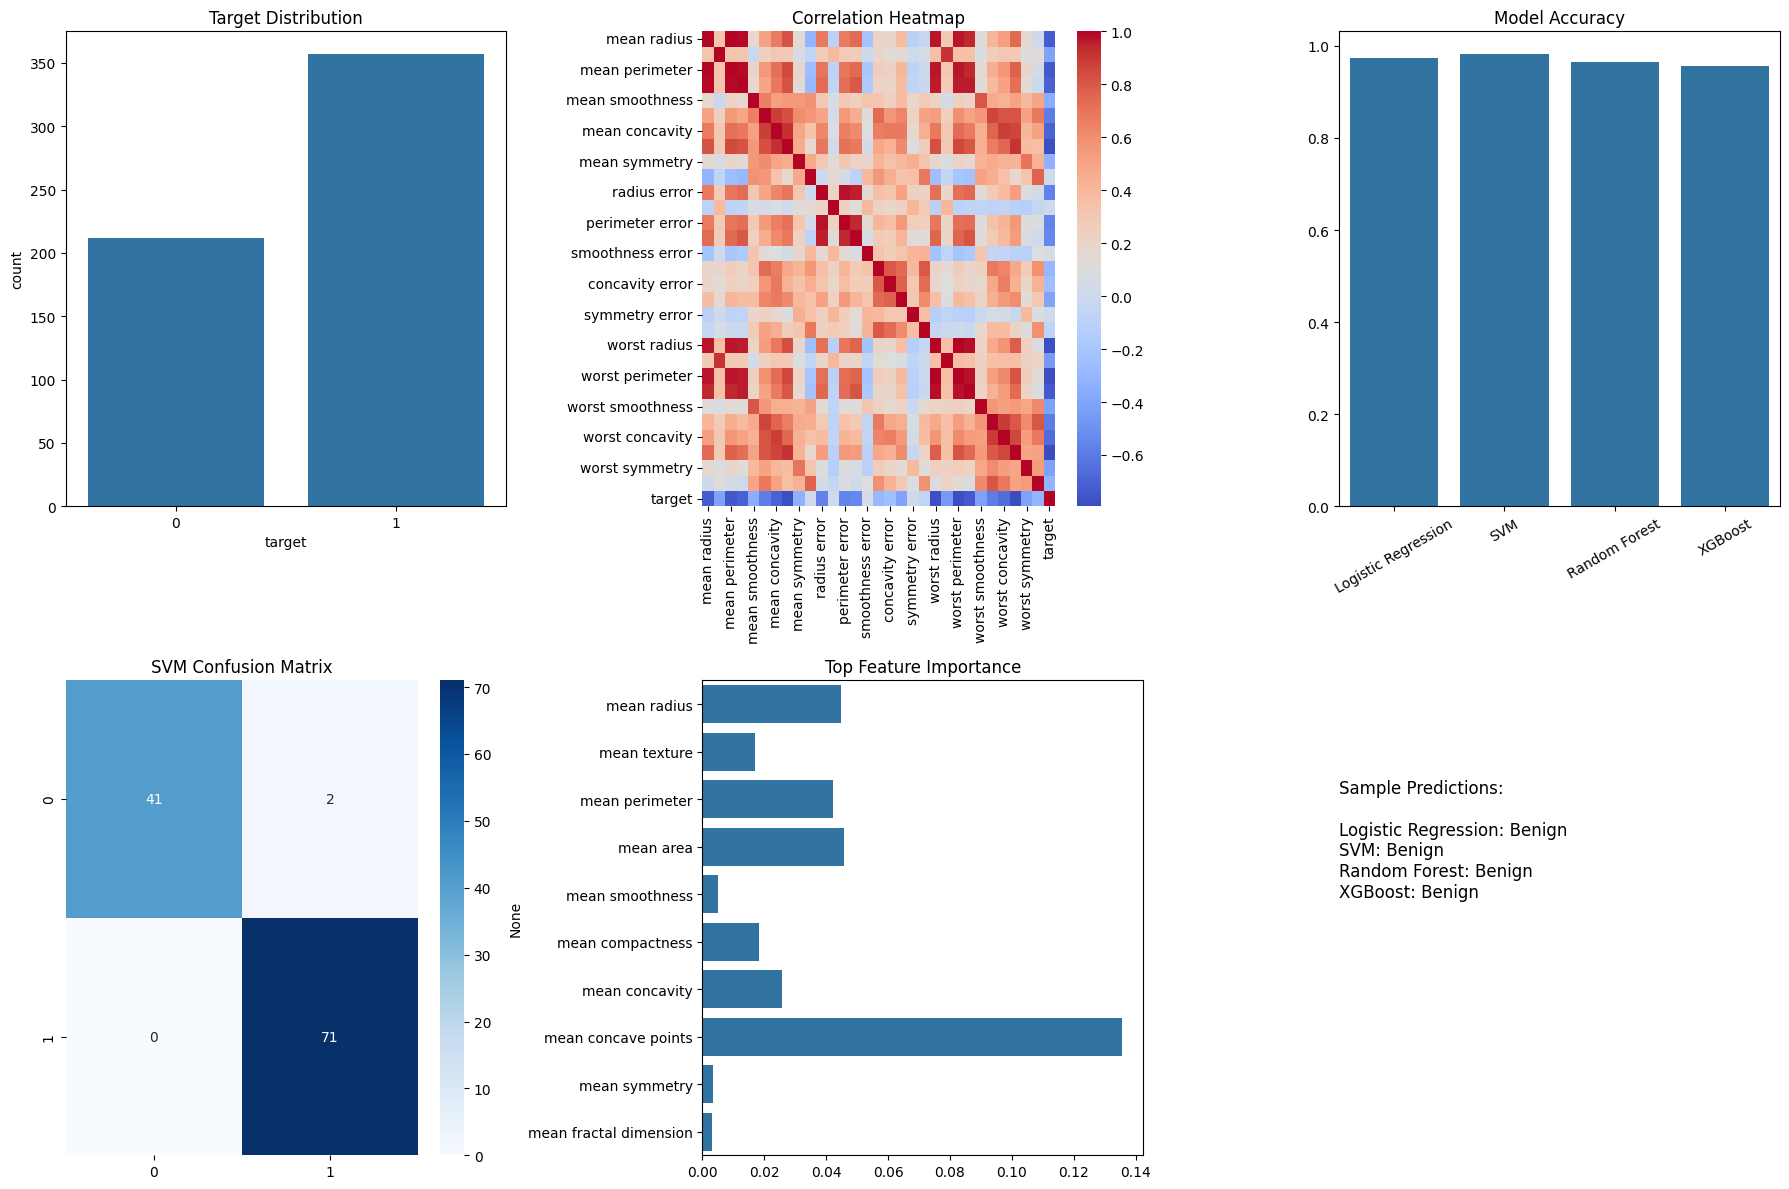


========== FINAL DASHBOARD ==========
Logistic Regression: 0.9737
SVM: 0.9825
Random Forest: 0.9649
XGBoost: 0.9561

Best Model: SVM
Best Accuracy: 0.9824561403508771

=== Detailed Report (SVM) ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
# ================================
#  DISEASE PREDICTION DASHBOARD
# ================================

# Install (if needed)
!pip install xgboost seaborn --quiet

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ================================
#  LOAD DATA
# ================================
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# ================================
#  PREPROCESSING
# ================================
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
#  TRAIN MODELS
# ================================
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    predictions[name] = pred
    results[name] = accuracy_score(y_test, pred)

# ================================
#  DASHBOARD VISUALIZATION
# ================================
plt.figure(figsize=(18, 12))

# 1️ Target Distribution
plt.subplot(2, 3, 1)
sns.countplot(x='target', data=df)
plt.title("Target Distribution")

# 2️ Correlation Heatmap
plt.subplot(2, 3, 2)
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")

# 3️ Accuracy Comparison
plt.subplot(2, 3, 3)
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=30)
plt.title("Model Accuracy")

# 4️ Confusion Matrix - Best Model
best_model = max(results, key=results.get)
cm = confusion_matrix(y_test, predictions[best_model])

plt.subplot(2, 3, 4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"{best_model} Confusion Matrix")

# 5️ Feature Importance (Random Forest)
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

plt.subplot(2, 3, 5)
sns.barplot(x=importances[:10], y=df.columns[:10])
plt.title("Top Feature Importance")

# 6️ Prediction Example
plt.subplot(2, 3, 6)
plt.axis('off')

sample = X_test[0].reshape(1, -1)

text = "Sample Predictions:\n\n"
for name, model in models.items():
    pred = model.predict(sample)[0]
    result = "Benign" if pred == 1 else "Malignant"
    text += f"{name}: {result}\n"

plt.text(0, 0.5, text, fontsize=12)

plt.tight_layout()
plt.show()

# ================================
#  FINAL SUMMARY
# ================================
print("\n========== FINAL DASHBOARD ==========")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])

# ================================
#  CLASSIFICATION REPORT
# ================================
print(f"\n=== Detailed Report ({best_model}) ===")
print(classification_report(y_test, predictions[best_model]))